In [1]:
import pandas as pd
import numpy as np

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

In [3]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

In [4]:
df = pd.read_csv("cleaned_twitter_data.csv")

In [5]:
df.head()

,USER_ID,ENTITY,SENTIMENT,TEXT
0,2401,Borderlands,Positive,im getting on borderlands and i will murder yo...
1,2401,Borderlands,Positive,I am coming to the borders and I will kill you...
2,2401,Borderlands,Positive,im getting on borderlands and i will kill you ...
3,2401,Borderlands,Positive,im coming on borderlands and i will murder you...
4,2401,Borderlands,Positive,im getting on borderlands 2 and i will murder ...


In [6]:
df.shape

(59118, 4)

In [7]:
df["SENTIMENT"].value_counts()

SENTIMENT
Negative    21698
Positive    19713
Neutral     17707
Name: count, dtype: int64

In [8]:
import re
import nltk

from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer, SnowballStemmer
from sklearn.feature_extraction.text import CountVectorizer

In [9]:
nltk.download("punkt")
nltk.download('punkt_tab')   
nltk.download("stopwords")

[nltk_data] Downloading package punkt to C:\Users\MANISA
[nltk_data]     GHOSH\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to C:\Users\MANISA
[nltk_data]     GHOSH\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to C:\Users\MANISA
[nltk_data]     GHOSH\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [10]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r"http\S+|www\S+", "", text)
    text = re.sub(r"@\w+", "", text)
    text = re.sub(r"[^a-zA-Z\s]", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    
    return text

In [11]:
df["CLEAN_TEXT"] = df["TEXT"].apply(clean_text)

In [12]:
df["TOKENS"] = df["CLEAN_TEXT"].apply(word_tokenize)

In [13]:
stop_words = set(stopwords.words("english")) - {"not", "no", "nor"}

In [14]:
df["NO_STOPWORDS"] = df["TOKENS"].apply(
    lambda tokens: [word for word in tokens if word not in stop_words]
)

In [15]:
porter = PorterStemmer()
snowball = SnowballStemmer("english")

In [16]:
from nltk.stem import WordNetLemmatizer

nltk.download("wordnet")
nltk.download("omw-1.4")

lemmatizer = WordNetLemmatizer()

df["LEMMATIZED"] = df["NO_STOPWORDS"].apply(
    lambda tokens: [lemmatizer.lemmatize(word) for word in tokens]
)

df["LEMMATIZED_TEXT"] = df["LEMMATIZED"].apply(
    lambda tokens: " ".join(tokens)
)

[nltk_data] Downloading package wordnet to C:\Users\MANISA
[nltk_data]     GHOSH\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to C:\Users\MANISA
[nltk_data]     GHOSH\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


In [17]:
df["SNOWBALL_STEMMED"] = df["NO_STOPWORDS"].apply(
    lambda tokens: [snowball.stem(word) for word in tokens]
)

df["SNOWBALL_TEXT"] = df["SNOWBALL_STEMMED"].apply(
    lambda tokens: " ".join(tokens)
)

In [18]:
df["PORTER_STEMMED"] = df["NO_STOPWORDS"].apply(
    lambda tokens: [porter.stem(word) for word in tokens]
)

df["PORTER_TEXT"] = df["PORTER_STEMMED"].apply(
    lambda tokens: " ".join(tokens)
)

In [19]:
X_snowball = df["SNOWBALL_TEXT"]
X_porter = df["PORTER_TEXT"]

y = df["SENTIMENT"]

In [20]:
X_train_idx, X_test_idx, y_train, y_test = train_test_split(
    df.index,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [21]:
snowball_train = df.loc[X_train_idx, "SNOWBALL_TEXT"]
snowball_test = df.loc[X_test_idx, "SNOWBALL_TEXT"]

lemmatized_train = df.loc[X_train_idx, "LEMMATIZED_TEXT"]
lemmatized_test = df.loc[X_test_idx, "LEMMATIZED_TEXT"]

In [22]:
print("Training samples:", len(X_train_idx))
print("Testing samples:", len(X_test_idx))

Training samples: 47294
Testing samples: 11824


**Configuration 1: TF-IDF + Snowball + (Bigram,Trigram)**

In [23]:
tfidf = TfidfVectorizer(
    ngram_range=(2, 3)
)

X_train_tfidf = tfidf.fit_transform(snowball_train)
X_test_tfidf = tfidf.transform(snowball_test)

**Configuration 2: BoW + Lemmatization + (Unigram, Bigram)**

In [51]:
bow = CountVectorizer(
    ngram_range=(1, 2),
    min_df=2
)

X_train_bow = bow.fit_transform(lemmatized_train)
X_test_bow = bow.transform(lemmatized_test)

**Check the feature sizes**

In [52]:
print("TF-IDF:", X_train_tfidf.shape)
print("BoW:", X_train_bow.shape)

TF-IDF: (47294, 442737)
BoW: (47294, 96802)


**Train the two Logistic Regression models**

    # TF-IDF + Snowball + ( Bigram , Trigram)
    # # BoW + Lemmatization + (Unigram, Bigram)

In [ ]:
from sklearn.linear_model import LogisticRegression

# TF-IDF + Snowball + (Bigram , Trigram)
tfidf_model = LogisticRegression(max_iter=1000)
tfidf_model.fit(X_train_tfidf, y_train)

tfidf_pred = tfidf_model.predict(X_test_tfidf)


# BoW + Lemmatization + (Unigram, Bigram)
bow_model = LogisticRegression(max_iter=1000)
bow_model.fit(X_train_bow, y_train)



,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is '

In [54]:

# Predictions on test data
bow_pred = bow_model.predict(X_test_bow)

In [55]:
# Predictions on training data before tuning
bow_before_tuning_train_predictions = bow_model.predict(X_train_bow)

# Training accuracy before tuning
bow_before_tuning_train_accuracy = accuracy_score(
    y_train,
    bow_before_tuning_train_predictions
)

# Predictions on test data before tuning
bow_before_tuning_test_predictions = bow_model.predict(X_test_bow)

# Testing accuracy before tuning
bow_before_tuning_test_accuracy = accuracy_score(
    y_test,
    bow_before_tuning_test_predictions
)

print("Training Accuracy Before Hyperparameter  Tuning:",
      bow_before_tuning_train_accuracy * 100)

print("Testing Accuracy Before Hyperparameter  Tuning:",
      bow_before_tuning_test_accuracy * 100)

Training Accuracy Before Hyperparameter  Tuning: 96.41815029390621
Testing Accuracy Before Hyperparameter  Tuning: 90.27401894451963


**Evaluate both models**

In [56]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# TF-IDF metrics
tfidf_accuracy = accuracy_score(y_test, tfidf_pred)
tfidf_precision = precision_score(y_test, tfidf_pred, average="weighted")
tfidf_recall = recall_score(y_test, tfidf_pred, average="weighted")
tfidf_f1 = f1_score(y_test, tfidf_pred, average="weighted")


# BoW metrics
bow_accuracy = accuracy_score(y_test, bow_pred)
bow_precision = precision_score(y_test, bow_pred, average="weighted")
bow_recall = recall_score(y_test, bow_pred, average="weighted")
bow_f1 = f1_score(y_test, bow_pred, average="weighted")

In [30]:
print("TF-IDF + Snowball + (Bigram,Trigram)\n ")
print("Accuracy :", tfidf_accuracy* 100)
print("Precision:", tfidf_precision)
print("Recall   :", tfidf_recall)
print("F1-Score :", tfidf_f1)

print("\nBoW + Lemmatization + (Unigram,Bigram) \n")
print("Accuracy :", bow_accuracy * 100)
print("Precision:", bow_precision)
print("Recall   :", bow_recall)
print("F1-Score :", bow_f1)

TF-IDF + Snowball + (Bigram,Trigram)
 
Accuracy : 89.45365358592693
Precision: 0.9035318265368393
Recall   : 0.8945365358592693
F1-Score : 0.8950003661425731

BoW + Lemmatization + (Unigram,Bigram) 

Accuracy : 90.39242219215156
Precision: 0.9054062198376334
Recall   : 0.9039242219215156
F1-Score : 0.9038838972764595


**Classification Report**

In [57]:
from sklearn.metrics import classification_report

print("TF-IDF + Snowball +(Bigram,Trigram) \n")
print(classification_report(y_test, tfidf_pred))

print("\nBoW + Lemmatization + (Unigram,Bigram) \n")
print(classification_report(y_test, bow_pred))

TF-IDF + Snowball +(Bigram,Trigram) 

              precision    recall  f1-score   support

    Negative       0.82      0.97      0.89      4340
     Neutral       0.96      0.86      0.91      3541
    Positive       0.95      0.85      0.90      3943

    accuracy                           0.89     11824
   macro avg       0.91      0.89      0.90     11824
weighted avg       0.90      0.89      0.90     11824


BoW + Lemmatization + (Unigram,Bigram) 

              precision    recall  f1-score   support

    Negative       0.92      0.91      0.92      4340
     Neutral       0.93      0.86      0.89      3541
    Positive       0.86      0.94      0.90      3943

    accuracy                           0.90     11824
   macro avg       0.90      0.90      0.90     11824
weighted avg       0.90      0.90      0.90     11824



**Confusion Matrix**

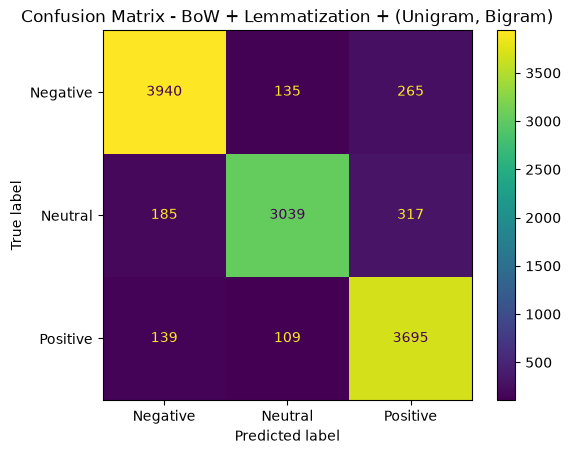

In [58]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, bow_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=bow_model.classes_
)

disp.plot()
plt.title("Confusion Matrix - BoW + Lemmatization + (Unigram, Bigram)")
plt.show()

    #1. Negative class
    #3940 → correctly predicted as Negative
    #140 → incorrectly predicted as Neutral
    #260 → incorrectly predicted as Positive

        #So the model correctly identifies most Negative texts.

    #2. Neutral class
    #3056 → correctly predicted as Neutral
    #186 → predicted as Negative
    #299 → predicted as Positive

        #The model has somewhat more difficulty distinguishing Neutral from Positive.

    #3. Positive class
    #3687 → correctly predicted as Positive
    #145 → predicted as Negative
    #111 → predicted as Neutral

        #Again, most Positive texts are correctly classified.

**Hyperparameter Tuning**

    # GridSearchCV

In [59]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "C": [0.001, 0.01, 0.05, 0.1, 0.2, 0.5, 1],
    "solver": ["lbfgs"],
    "max_iter": [1000]
}

In [60]:
grid_search = GridSearchCV(
    estimator=LogisticRegression(),
    param_grid=param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

In [61]:
grid_search.fit(X_train_bow, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LogisticRegression()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': [0.001, 0.01, ...], 'max_iter': [1000], 'solver': ['lbfgs']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0Controls the verbosity of informatio

In [62]:
print("Best Parameters:")
print(grid_search.best_params_)

Best Parameters:
{'C': 1, 'max_iter': 1000, 'solver': 'lbfgs'}


In [63]:
print("Best Cross-Validation Accuracy:")
print(grid_search.best_score_ * 100)

Best Cross-Validation Accuracy:
89.72807440358007


In [64]:
best_model = grid_search.best_estimator_

best_pred = best_model.predict(X_test_bow)

**Evaluate the tuned model**

In [65]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

tuned_accuracy = accuracy_score(y_test, best_pred)
tuned_precision = precision_score(
    y_test, best_pred, average="weighted"
)
tuned_recall = recall_score(
    y_test, best_pred, average="weighted"
)
tuned_f1 = f1_score(
    y_test, best_pred, average="weighted"
)

print("Hyperparameter Tuned Logistic Regression\n")
print("Accuracy :", tuned_accuracy * 100)
print("Precision:", tuned_precision)
print("Recall   :", tuned_recall)
print("F1-Score :", tuned_f1)

Hyperparameter Tuned Logistic Regression

Accuracy : 90.27401894451963
Precision: 0.9044739183223763
Recall   : 0.9027401894451962
F1-Score : 0.9027032021181182


In [66]:
# Predictions on training data after tuning
bow_after_tuning_train_predictions = best_model.predict(X_train_bow)

# Training accuracy after tuning
bow_after_tuning_train_accuracy = accuracy_score(
    y_train,
    bow_after_tuning_train_predictions
)

# Predictions on test data after tuning
bow_after_tuning_test_predictions = best_model.predict(X_test_bow)

# Testing accuracy after tuning
bow_after_tuning_test_accuracy = accuracy_score(
    y_test,
    bow_after_tuning_test_predictions
)

print("Training Accuracy After Hyperparameter Tuning:",
      bow_after_tuning_train_accuracy * 100)

print("Testing Accuracy After Hyperparameter Tuning:",
      bow_after_tuning_test_accuracy * 100)

Training Accuracy After Hyperparameter Tuning: 96.41815029390621
Testing Accuracy After Hyperparameter Tuning: 90.27401894451963


In [67]:
accuracy_comparison = pd.DataFrame({
    "Model": [
        "Before Hyperparameter Tuning",
        "After  Hyperparameter Tuning"
    ],
    "Training Accuracy": [
        bow_before_tuning_train_accuracy * 100,
        bow_after_tuning_train_accuracy * 100
    ],
    "Testing Accuracy": [
        bow_before_tuning_test_accuracy * 100,
        bow_after_tuning_test_accuracy * 100
    ]
})

accuracy_comparison

,Model,Training Accuracy,Testing Accuracy
0,Before Hyperparameter Tuning,96.41815,90.274019
1,After Hyperparameter Tuning,96.41815,90.274019


In [68]:
print("Original BoW Test Accuracy :", bow_before_tuning_test_accuracy * 100)
print("Hyperparameter Tuned BoW Test Accuracy    :", bow_after_tuning_test_accuracy * 100)

Original BoW Test Accuracy : 90.27401894451963
Hyperparameter Tuned BoW Test Accuracy    : 90.27401894451963


In [69]:
print("Best Parameters:", grid_search.best_params_)
print("Best CV Accuracy:", grid_search.best_score_)

print("Train Accuracy:", bow_after_tuning_train_accuracy)
print("Test Accuracy:", bow_after_tuning_test_accuracy)

gap = bow_after_tuning_train_accuracy - bow_after_tuning_test_accuracy
print("Train-Test Gap:", gap)

Best Parameters: {'C': 1, 'max_iter': 1000, 'solver': 'lbfgs'}
Best CV Accuracy: 0.8972807440358006
Train Accuracy: 0.964181502939062
Test Accuracy: 0.9027401894451962
Train-Test Gap: 0.061441313493865835


In [70]:
print(classification_report(y_test, best_pred))

              precision    recall  f1-score   support

    Negative       0.92      0.91      0.92      4340
     Neutral       0.93      0.86      0.89      3541
    Positive       0.86      0.94      0.90      3943

    accuracy                           0.90     11824
   macro avg       0.90      0.90      0.90     11824
weighted avg       0.90      0.90      0.90     11824



In [71]:
print(confusion_matrix(y_test, best_pred))

[[3940  135  265]
 [ 185 3039  317]
 [ 139  109 3695]]


In [72]:
import joblib

joblib.dump(bow, "bow_Vectorizer.pkl")
joblib.dump(grid_search.best_estimator_, "bow_sentiment_model.pkl")

['bow_sentiment_model.pkl']

In [73]:
joblib.dump(tfidf, "tfidf_vectorizer.pkl")
joblib.dump(tfidf_model, "tfidf_sentiment_model.pkl")

['tfidf_sentiment_model.pkl']